# Anime → CelebA alignment tuning

**Goal:** find `scale`, `shift_x`, `shift_y` for a fixed crop transform that maps anime faces to the same position as CelebA faces.

**Workflow:**
1. Run the setup cells once — computes CelebA canonical (average landmark positions in 128×128 space)
2. Use the interactive slider cell to tune the anime transform
3. Copy the printed params into config / dataset code

In [1]:
import sys
sys.path.insert(0, '..')

import random
from pathlib import Path

import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision as mp_vision
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image
import ipywidgets as widgets
from IPython.display import display

from kaoanime.utils.align import _ensure_model, _src_pts

In [2]:
ROOT_A     = Path('/beta/home/madorskii/datasets/CelebA/img_align_celeba/img_align_celeba')
ROOT_B     = Path('/beta/home/madorskii/datasets/alignedanimefaces/safebooru_jpeg')
IMAGE_SIZE = 128      # output resolution
N_CELEBA   = 200      # images used to compute the CelebA canonical
N_GRID     = 20       # anime images shown in the interactive grid
N_REF      = 10       # CelebA images shown in the reference grid
SEED       = 7

# Landmark colours: L-eye, R-eye, Nose, L-mouth, R-mouth
COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
LABELS = ['L-eye', 'R-eye', 'Nose', 'L-mouth', 'R-mouth']

## Step 1 — Compute CelebA canonical
Center-crop each CelebA image to `IMAGE_SIZE×IMAGE_SIZE`, run MediaPipe, average the 5-point positions.
This is the **target** that the anime transform should reproduce.

In [3]:
def collect(root: Path, n: int, seed: int = SEED) -> list[Path]:
    exts = {'.jpg', '.jpeg', '.png'}
    files = [p for p in root.iterdir() if p.suffix.lower() in exts]
    return random.Random(seed).sample(files, min(n, len(files)))

def preprocess_celeba(path: Path, size: int) -> np.ndarray:
    """Load image and resize directly to size×size (matches training transform)."""
    img = Image.open(path).convert('RGB')
    return np.array(img.resize((size, size), Image.LANCZOS))

options = mp_vision.FaceLandmarkerOptions(
    base_options=mp_tasks.BaseOptions(model_asset_path=_ensure_model()),
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1,
)
landmarker = mp_vision.FaceLandmarker.create_from_options(options)

def detect_5pt(img_rgb: np.ndarray) -> np.ndarray | None:
    """Returns (5,2) array of (x,y) landmark positions, or None."""
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = landmarker.detect(mp_img)
    if not result.face_landmarks:
        return None
    h, w = img_rgb.shape[:2]
    return _src_pts(result.face_landmarks[0], h, w)

W0000 00:00:1778958966.079030 3541206 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1778958966.316235 3541206 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1778958966.443341 3541259 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 570.172.08), renderer: NVIDIA A100 80GB PCIe/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778958966.452775 3541211 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778958966.473593 3541226 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [4]:
print(f'Computing CelebA canonical from {N_CELEBA} images…')
celeba_files = collect(ROOT_A, N_CELEBA)
all_pts = []
for i, p in enumerate(celeba_files):
    img = preprocess_celeba(p, IMAGE_SIZE)
    pts = detect_5pt(img)
    if pts is not None:
        all_pts.append(pts)
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{N_CELEBA}  detected: {len(all_pts)}')

canonical = np.mean(all_pts, axis=0)  # (5, 2)  in 128×128 pixel space
print(f'\nCelebA canonical (averaged over {len(all_pts)} detected faces):')
for label, (x, y) in zip(LABELS, canonical):
    print(f'  {label:10s}  x={x:.1f}  y={y:.1f}')

Computing CelebA canonical from 200 images…
  50/200  detected: 49
  100/200  detected: 99
  150/200  detected: 149
  200/200  detected: 199

CelebA canonical (averaged over 199 detected faces):
  L-eye       x=77.2  y=65.7
  R-eye       x=50.2  y=65.7
  Nose        x=62.6  y=78.6
  L-mouth     x=51.8  y=89.5
  R-mouth     x=75.4  y=89.5


## Step 2 — CelebA reference grid
Colored crosses show the **average** canonical position. Individual detected points are faint dots.
This is what aligned anime faces should look like.

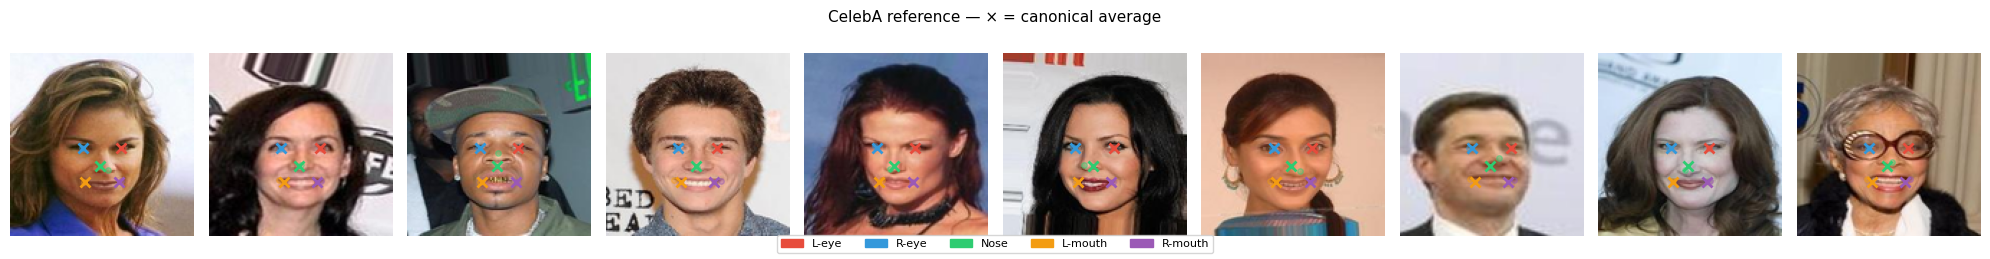

In [5]:
ref_files = collect(ROOT_A, N_REF, seed=SEED + 1)
ref_imgs  = [preprocess_celeba(p, IMAGE_SIZE) for p in ref_files]
ref_pts   = [detect_5pt(img) for img in ref_imgs]

cols = N_REF
fig, axes = plt.subplots(1, cols, figsize=(cols * 2, 2.5))
fig.suptitle('CelebA reference — × = canonical average', fontsize=11)

for ax, img, pts in zip(axes, ref_imgs, ref_pts):
    ax.imshow(img)
    if pts is not None:
        # individual dots (faint)
        for (x, y), c in zip(pts, COLORS):
            ax.plot(x, y, 'o', color=c, markersize=4, alpha=0.4)
    # canonical average (bold cross)
    for (x, y), c in zip(canonical, COLORS):
        ax.plot(x, y, 'x', color=c, markersize=7, markeredgewidth=2)
    ax.axis('off')

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=8)
plt.tight_layout()
plt.show()

## Step 3 — Interactive anime transform

The transform crops a square region from the anime image and resizes it to `IMAGE_SIZE×IMAGE_SIZE`:
- **scale** — zoom factor. `2.0` means the crop covers half the image side → face appears 2× larger
- **shift_x** — horizontal shift of the crop centre, as a fraction of image width (negative = left)
- **shift_y** — vertical shift of the crop centre, as a fraction of image height (negative = up)

Colored **crosses** show the CelebA canonical target positions.  
Adjust the sliders until anime faces land on the crosses.

In [ ]:
# Pre-load anime images (raw PIL, variable size) once
anime_files = collect(ROOT_B, N_GRID, seed=SEED + 2)
anime_raw   = [Image.open(p).convert('RGB') for p in anime_files]


def apply_transform(img: Image.Image, scale: float, shift_x: float, shift_y: float) -> np.ndarray:
    w, h = img.size
    crop = int(min(w, h) / scale)
    cx = w / 2 + shift_x * w
    cy = h / 2 + shift_y * h
    x0 = int(max(0, cx - crop / 2))
    y0 = int(max(0, cy - crop / 2))
    x1 = min(w, x0 + crop)
    y1 = min(h, y0 + crop)
    return np.array(img.crop((x0, y0, x1, y1)).resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS))

COLS = 5
ROWS = N_GRID // COLS

out = widgets.Output()

scale_slider   = widgets.FloatSlider(value=1.5, min=1.0, max=4.0, step=0.05,
                                      description='scale', continuous_update=False,
                                      style={'description_width': '60px'}, layout=widgets.Layout(width='500px'))
shift_x_slider = widgets.FloatSlider(value=0.0, min=-0.4, max=0.4, step=0.01,
                                      description='shift_x', continuous_update=False,
                                      style={'description_width': '60px'}, layout=widgets.Layout(width='500px'))
shift_y_slider = widgets.FloatSlider(value=0.0, min=-0.4, max=0.4, step=0.01,
                                      description='shift_y', continuous_update=False,
                                      style={'description_width': '60px'}, layout=widgets.Layout(width='500px'))

def redraw(change=None):
    scale   = scale_slider.value
    shift_x = shift_x_slider.value
    shift_y = shift_y_slider.value
    crops = [apply_transform(img, scale, shift_x, shift_y) for img in anime_raw]
    with out:
        out.clear_output(wait=True)
        fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 2.2, ROWS * 2.4))
        fig.suptitle(f'Anime transform  scale={scale:.2f}  shift_x={shift_x:.2f}  shift_y={shift_y:.2f}',
                     fontsize=11)
        for ax, img in zip(axes.flat, crops):
            ax.imshow(img)
            for (x, y), c in zip(canonical, COLORS):
                ax.plot(x, y, 'x', color=c, markersize=9, markeredgewidth=2)
            ax.axis('off')
        patches = [mpatches.Patch(color=c, label=l) for c, l in zip(COLORS, LABELS)]
        fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=8)
        plt.tight_layout()
        plt.show()

for slider in (scale_slider, shift_x_slider, shift_y_slider):
    slider.observe(redraw, names='value')

display(widgets.VBox([scale_slider, shift_x_slider, shift_y_slider, out]))
redraw()

## Step 4 — Print final params
Run this cell after you are happy with the sliders.

In [7]:
scale   = scale_slider.value
shift_x = shift_x_slider.value
shift_y = shift_y_slider.value

print('=== Optimal anime transform params ===')
print(f'  scale   = {scale:.2f}')
print(f'  shift_x = {shift_x:.2f}')
print(f'  shift_y = {shift_y:.2f}')
print()
print('=== CelebA canonical (paste into align.py as the inference target) ===')
print('_CELEBA_CELEBA_REF_128 = np.array([')
for label, (x, y) in zip(LABELS, canonical):
    print(f'    [{x:.1f}, {y:.1f}],  # {label}')
print('], dtype=np.float32)')
print()
print('=== DataConfig fields to add ===')
print(f'    anime_scale   : float = {scale:.2f}')
print(f'    anime_shift_x : float = {shift_x:.2f}')
print(f'    anime_shift_y : float = {shift_y:.2f}')

=== Optimal anime transform params ===
  scale   = 1.20
  shift_x = 0.00
  shift_y = -0.02

=== CelebA canonical (paste into align.py as the inference target) ===
_CELEBA_CELEBA_REF_128 = np.array([
    [77.2, 65.7],  # L-eye
    [50.2, 65.7],  # R-eye
    [62.6, 78.6],  # Nose
    [51.8, 89.5],  # L-mouth
    [75.4, 89.5],  # R-mouth
], dtype=np.float32)

=== DataConfig fields to add ===
    anime_scale   : float = 1.20
    anime_shift_x : float = 0.00
    anime_shift_y : float = -0.02
